# Vergleich: Szenenklassifikation


In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, mannwhitneyu, spearmanr, f_oneway


In [3]:
DATA_DIR = Path('../../data')

INPUT_CSV = DATA_DIR / '04_analysis_results' / 'visual_features' / '06_AI_AND_REAL_TIKTOK_VIDEOS_stratified_with_scene_classification.csv'
print(f'Reading {INPUT_CSV}')
df = pd.read_csv(INPUT_CSV)

if 'influencer_type' not in df.columns and 'source' in df.columns:
    df['influencer_type'] = df['source']

if 'video_engagement_rate' not in df.columns:
    like_col = 'video_like_count' if 'video_like_count' in df.columns else ('likes' if 'likes' in df.columns else None)
    comment_col = 'video_comment_count' if 'video_comment_count' in df.columns else ('comments' if 'comments' in df.columns else None)
    share_col = 'video_share_count' if 'video_share_count' in df.columns else ('shares' if 'shares' in df.columns else None)
    view_col = 'video_view_count' if 'video_view_count' in df.columns else ('plays' if 'plays' in df.columns else None)
    if all(c is not None for c in [like_col, comment_col, share_col, view_col]):
        df['video_engagement_rate'] = (
            df[like_col].fillna(0) + df[comment_col].fillna(0) + df[share_col].fillna(0)
        ) / df[view_col].replace(0, pd.NA)

print(df[['influencer_type', 'scene_top1_confidence', 'scene_unique_labels']].groupby('influencer_type').agg(['count', 'mean', 'std']))


Reading ../../data/04_analysis_results/visual_features/06_AI_AND_REAL_TIKTOK_VIDEOS_stratified_with_scene_classification.csv                scene_top1_confidence                     scene_unique_labels  \                                count      mean       std               count   influencer_type                                                                 ai                                250  0.455297  0.197521                 250   real                              250  0.464482  0.190233                 250                                                       mean       std  influencer_type                   ai               3.952  4.240474  real             7.192  7.588510  

In [3]:
FRAME_ROOT = DATA_DIR / '02_media/stratified_sample/frames'

def get_video_id(row):
    return str(row.get('id') or row.get('video_id'))

def first_frame_path(video_id: str):
    folder = FRAME_ROOT / video_id
    if not folder.is_dir():
        return None
    frames = sorted(folder.glob('*.jpeg'))
    if not frames:
        frames = sorted(folder.glob('*.jpg'))
    if not frames:
        return None
    return frames[len(frames) // 2]

def load_image(path):
    import cv2
    img = cv2.imread(str(path))
    if img is None:
        return None
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


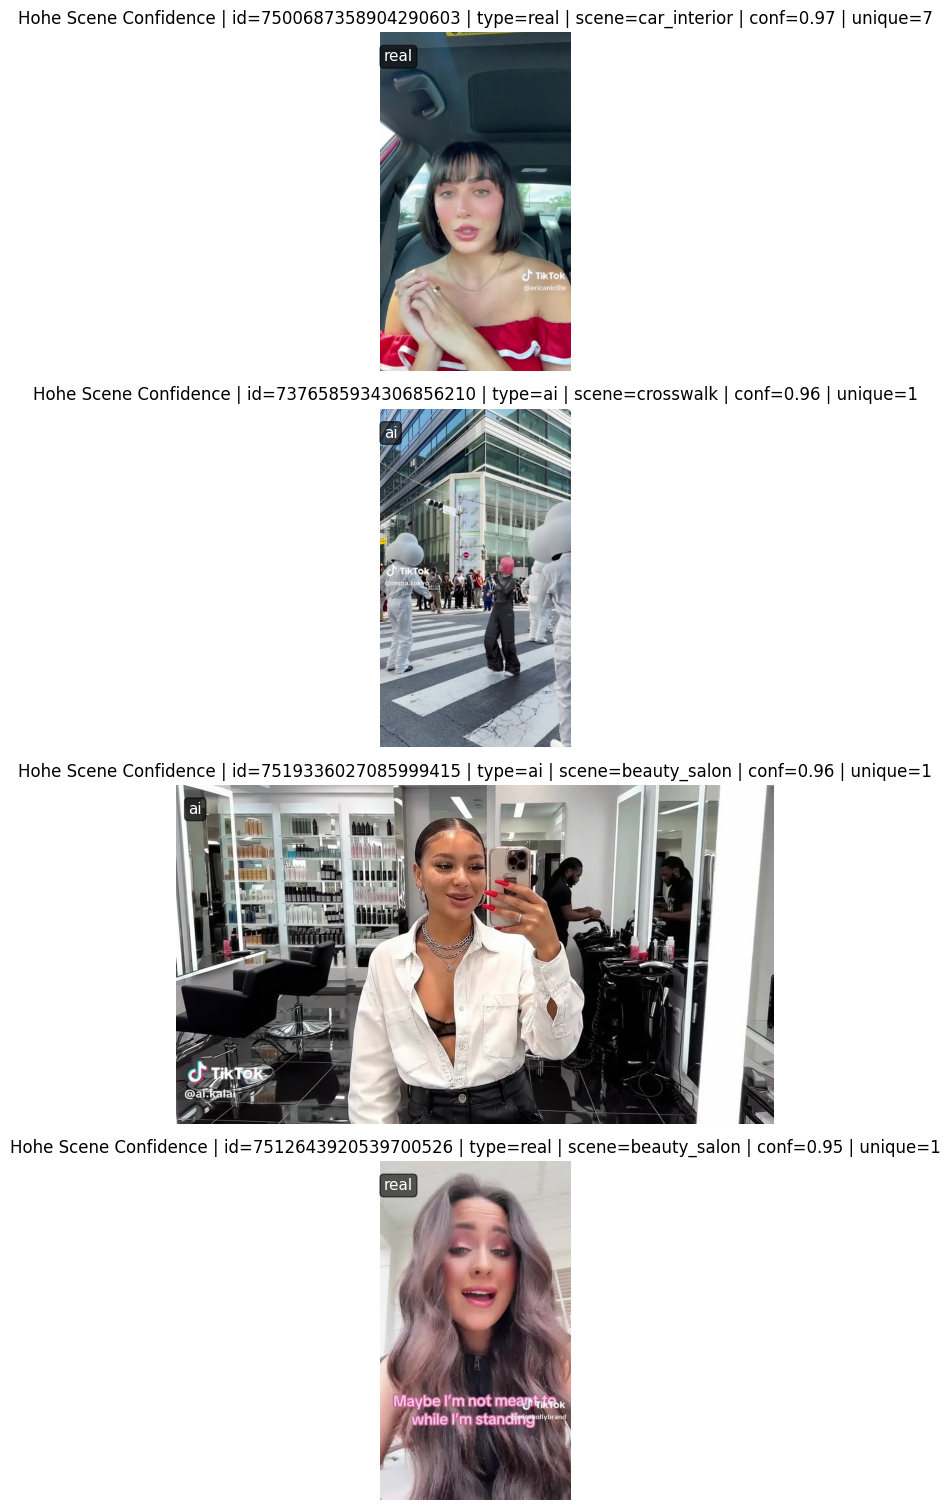

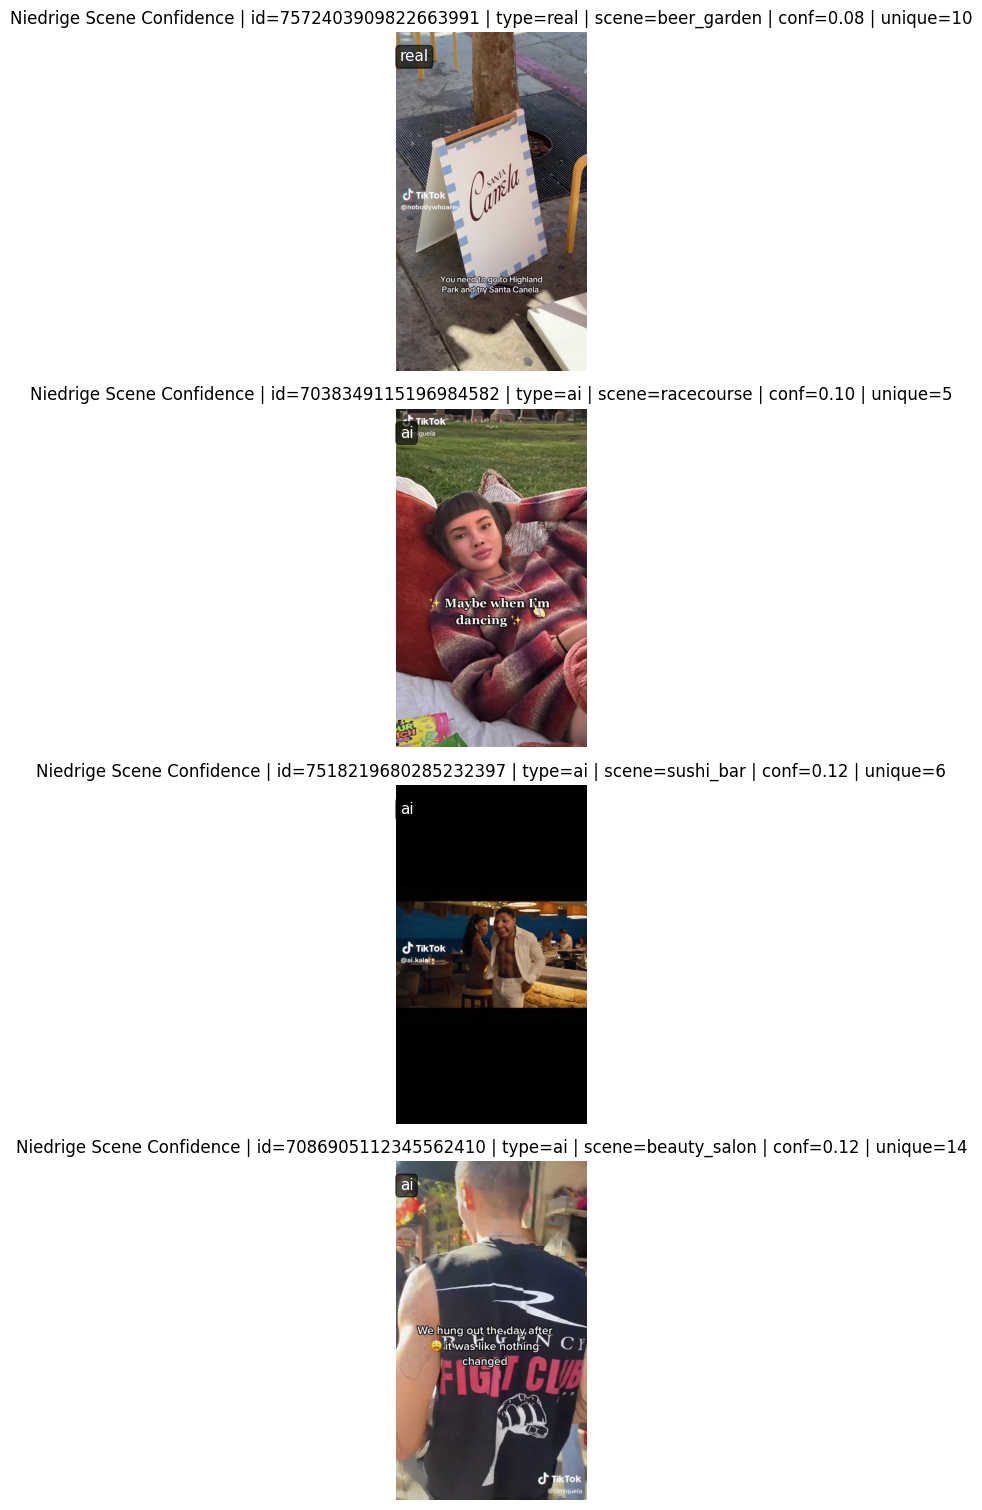

In [4]:
# Beispiele mit hoher und niedriger Szenen-Konfidenz anzeigen
_df = df.dropna(subset=['scene_top1_confidence']).copy()

def pick_examples(df_sorted, n=4):
    rows = []
    for _, row in df_sorted.iterrows():
        vid = get_video_id(row)
        fp = first_frame_path(vid)
        if fp is None:
            continue
        row = row.copy()
        row['frame_path'] = fp
        rows.append(row)
        if len(rows) >= n:
            break
    return rows

def show_examples(rows, title):
    if not rows:
        print(f'No frames found for {title}')
        return

    plt.figure(figsize=(12, 3.8 * len(rows)))
    for i, row in enumerate(rows, 1):
        img = load_image(row['frame_path'])
        ax = plt.subplot(len(rows), 1, i)
        if img is not None:
            ax.imshow(img)
            ax.axis('off')
        else:
            ax.text(0.5, 0.5, 'Image load failed', ha='center', va='center')
            ax.axis('off')

        conf = row['scene_top1_confidence']
        label = row.get('scene_top1_label', '')
        unique_n = row.get('scene_unique_labels', np.nan)
        inf = row.get('influencer_type', '')
        vid = get_video_id(row)
        ax.text(0.02, 0.95, f'{inf}', transform=ax.transAxes, ha='left', va='top',
                fontsize=11, color='white',
                bbox=dict(boxstyle='round,pad=0.25', fc='black', alpha=0.6))
        ax.set_title(
            f'{title} | id={vid} | type={inf} | scene={label} | conf={conf:.2f} | unique={unique_n}'
        )

    plt.tight_layout()
    plt.show()

high_conf = pick_examples(_df.sort_values('scene_top1_confidence', ascending=False), n=4)
low_conf = pick_examples(_df.sort_values('scene_top1_confidence', ascending=True), n=4)

show_examples(high_conf, 'Hohe Scene Confidence')
show_examples(low_conf, 'Niedrige Scene Confidence')


In [3]:
summary = df.groupby('influencer_type')[['scene_top1_confidence', 'scene_unique_labels']].describe().round(2)
display(summary)

top_labels = (
    df.groupby(['scene_top1_label', 'influencer_type'])
      .size()
      .unstack(fill_value=0)
      .sort_values(by=list(df['influencer_type'].dropna().unique())[:1], ascending=False)
      .head(15)
)
display(top_labels)


scene_top1_confidence                                      \
                                count  mean   std   min   25%   50%   75%   
influencer_type                                                             
ai                              250.0  0.46  0.20  0.10  0.31  0.42  0.55   
real                            250.0  0.46  0.19  0.08  0.32  0.43  0.60   

                      scene_unique_labels                                  \
                  max               count  mean   std  min  25%  50%  75%   
influencer_type                                                             
ai               0.96               250.0  3.95  4.24  1.0  2.0  2.5  4.0   
real             0.97               250.0  7.19  7.59  1.0  2.0  5.0  9.0   

                       
                  max  
influencer_type        
ai               25.0  
real             54.0

influencer_type,ai,real
scene_top1_label,,
beauty_salon,91,97
stage/indoor,17,2
playroom,16,0
dressing_room,9,2
car_interior,8,9
elevator/door,7,0
childs_room,6,0
arena/performance,5,0
toyshop,4,0


/var/folders/xv/tws3wcdj24b6nwt9_f_365jr0000gn/T/ipykernel_91813/2104007942.py:208: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


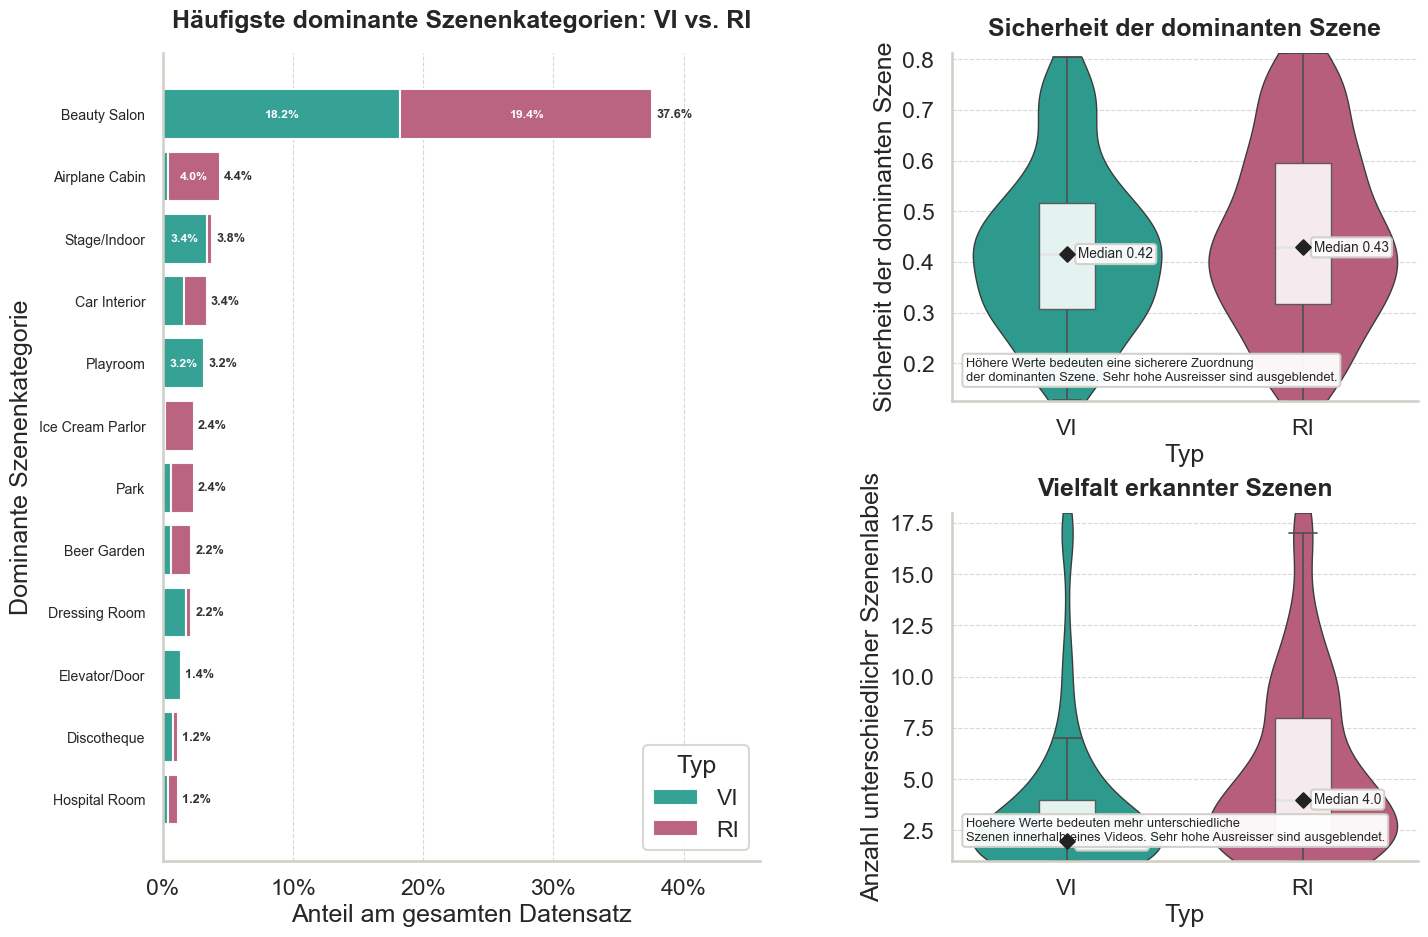

In [4]:
# Visualisierung der Szenenklassifikation
sns.set_theme(
    style='whitegrid',
    context='talk',
    rc={
        'axes.facecolor': 'white',
        'figure.facecolor': 'white',
        'grid.color': '#d9d9d2',
        'grid.linestyle': '--',
        'grid.linewidth': 0.8,
        'axes.edgecolor': '#d0d0c8',
    },
)

ORDER = ['VI', 'RI']
PALETTE_COLOR = {'VI': '#2A9D8F', 'RI': '#B85C7A'}

df_plot = df.copy()
df_plot['typ'] = df_plot['influencer_type'].map({'ai': 'VI', 'real': 'RI'}).fillna(df_plot['influencer_type'])
df_plot['scene_label_plot'] = (
    df_plot['scene_top1_label']
    .fillna('Unbestimmt')
    .astype(str)
    .str.replace('_', ' ', regex=False)
    .str.strip()
    .str.title()
)

scene_counts = (
    df_plot.groupby(['scene_label_plot', 'typ']).size().unstack(fill_value=0).reindex(columns=ORDER, fill_value=0)
)
scene_counts['gesamt'] = scene_counts.sum(axis=1)
total_scene_count = int(scene_counts[ORDER].to_numpy().sum())
if total_scene_count == 0:
    raise ValueError('Keine gültigen dominanten Szenenkategorien für VI und RI gefunden.')
scene_counts = scene_counts.sort_values('gesamt', ascending=False).head(12).sort_values('gesamt', ascending=True)
# Alle Anteile beziehen sich auf sämtliche gültigen Videos, nicht auf die einzelne Kategorie.
scene_shares = scene_counts[ORDER].div(total_scene_count)
scene_shares['gesamt'] = scene_shares[ORDER].sum(axis=1)
scene_labels = scene_shares.index.tolist()

gs = plt.figure(figsize=(16.2, max(10.5, 0.42 * len(scene_labels) + 3.8))).add_gridspec(2, 2, width_ratios=[1.28, 1.0], height_ratios=[1, 1], wspace=0.36, hspace=0.32)
ax_bar = plt.subplot(gs[:, 0])
ax_conf = plt.subplot(gs[0, 1])
ax_div = plt.subplot(gs[1, 1])

# 1) Häufigste Szenenkategorien als horizontale, gestapelte Balken
y_pos = np.arange(len(scene_labels))
ax_bar.barh(y_pos, scene_shares['VI'], color=PALETTE_COLOR['VI'], alpha=0.95, label='VI')
ax_bar.barh(y_pos, scene_shares['RI'], left=scene_shares['VI'], color=PALETTE_COLOR['RI'], alpha=0.95, label='RI')
ax_bar.set_title('Häufigste dominante Szenenkategorien: VI vs. RI', pad=18, weight='semibold')
ax_bar.set_xlabel('Anteil am gesamten Datensatz')
ax_bar.set_ylabel('Dominante Szenenkategorie')
ax_bar.set_yticks(y_pos)
ax_bar.set_yticklabels(scene_labels, fontsize=10.2)
ax_bar.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax_bar.grid(axis='y', visible=False)
ax_bar.legend(title='Typ', frameon=True, facecolor='white', edgecolor='#d0d0c8', loc='lower right')
max_scene_share = float(scene_shares['gesamt'].max())
ax_bar.set_xlim(0, max_scene_share * 1.22)

for i, (_, row) in enumerate(scene_shares.iterrows()):
    vi_share = row['VI']
    ri_share = row['RI']
    total_share = row['gesamt']

    if vi_share >= 0.025:
        ax_bar.text(vi_share / 2, i, f'{vi_share:.1%}', ha='center', va='center', fontsize=8.8, color='white', weight='semibold')
    if ri_share >= 0.025:
        ax_bar.text(vi_share + ri_share / 2, i, f'{ri_share:.1%}', ha='center', va='center', fontsize=8.8, color='white', weight='semibold')

    # Rechts steht der Gesamtanteil der Szene an allen gültigen Videos.
    ax_bar.text(total_share + 0.003, i, f'{total_share:.1%}', ha='left', va='center', fontsize=9.2, color='#333333', weight='semibold')

# 2) Top-1-Konfidenz nach Typ
conf_df = df_plot.dropna(subset=['scene_top1_confidence']).copy()
conf_low, conf_high = conf_df['scene_top1_confidence'].quantile([0.01, 0.95])
conf_plot_df = conf_df[(conf_df['scene_top1_confidence'] >= conf_low) & (conf_df['scene_top1_confidence'] <= conf_high)].copy()
conf_summary = (
    conf_plot_df.groupby('typ')['scene_top1_confidence']
    .agg(median='median', q1=lambda s: s.quantile(0.25), q3=lambda s: s.quantile(0.75))
    .reindex(ORDER)
)
sns.violinplot(
    data=conf_plot_df,
    x='typ',
    y='scene_top1_confidence',
    hue='typ',
    order=ORDER,
    hue_order=ORDER,
    palette=PALETTE_COLOR,
    inner=None,
    cut=0,
    linewidth=1.0,
    saturation=0.95,
    legend=False,
    ax=ax_conf,
)
sns.boxplot(
    data=conf_plot_df,
    x='typ',
    y='scene_top1_confidence',
    order=ORDER,
    width=0.24,
    fliersize=0,
    boxprops={'facecolor': 'white', 'alpha': 0.88, 'edgecolor': '#4f4f4f', 'zorder': 3},
    whiskerprops={'linewidth': 1.2, 'color': '#4f4f4f'},
    capprops={'linewidth': 1.2, 'color': '#4f4f4f'},
    medianprops={'color': '#222222', 'linewidth': 1.8},
    ax=ax_conf,
)
for x, grp in enumerate(ORDER):
    median_val = conf_summary.loc[grp, 'median']
    ax_conf.scatter(x, median_val, s=55, color='#222222', marker='D', zorder=4)
    ax_conf.annotate(
        f'Median {median_val:.2f}',
        (x, median_val),
        xytext=(8, 0),
        textcoords='offset points',
        va='center',
        fontsize=9.8,
        bbox=dict(boxstyle='round,pad=0.22', facecolor='white', edgecolor='#d0d0c8', alpha=0.95),
    )
ax_conf.set_title('Sicherheit der dominanten Szene', pad=12, weight='semibold')
ax_conf.set_xlabel('Typ')
ax_conf.set_ylabel('Sicherheit der dominanten Szene')
ax_conf.grid(axis='x', visible=False)
ax_conf.set_ylim(conf_low, conf_high)
ax_conf.text(
    0.03,
    0.05,
    'Höhere Werte bedeuten eine sicherere Zuordnung\nder dominanten Szene. Sehr hohe Ausreisser sind ausgeblendet.',
    transform=ax_conf.transAxes,
    ha='left',
    va='bottom',
    fontsize=9.3,
    bbox=dict(boxstyle='round,pad=0.25', facecolor='white', edgecolor='#d0d0c8', alpha=0.95),
)

# 3) Szenenvielfalt nach Typ
unique_df = df_plot.dropna(subset=['scene_unique_labels']).copy()
unique_low, unique_high = unique_df['scene_unique_labels'].quantile([0.01, 0.95])
unique_plot_df = unique_df[(unique_df['scene_unique_labels'] >= unique_low) & (unique_df['scene_unique_labels'] <= unique_high)].copy()
unique_summary = (
    unique_plot_df.groupby('typ')['scene_unique_labels']
    .agg(median='median', q1=lambda s: s.quantile(0.25), q3=lambda s: s.quantile(0.75))
    .reindex(ORDER)
)
sns.violinplot(
    data=unique_plot_df,
    x='typ',
    y='scene_unique_labels',
    hue='typ',
    order=ORDER,
    hue_order=ORDER,
    palette=PALETTE_COLOR,
    inner=None,
    cut=0,
    linewidth=1.0,
    saturation=0.95,
    legend=False,
    ax=ax_div,
)
sns.boxplot(
    data=unique_plot_df,
    x='typ',
    y='scene_unique_labels',
    order=ORDER,
    width=0.24,
    fliersize=0,
    boxprops={'facecolor': 'white', 'alpha': 0.88, 'edgecolor': '#4f4f4f', 'zorder': 3},
    whiskerprops={'linewidth': 1.2, 'color': '#4f4f4f'},
    capprops={'linewidth': 1.2, 'color': '#4f4f4f'},
    medianprops={'color': '#222222', 'linewidth': 1.8},
    ax=ax_div,
)
for x, grp in enumerate(ORDER):
    median_val = unique_summary.loc[grp, 'median']
    ax_div.scatter(x, median_val, s=55, color='#222222', marker='D', zorder=4)
    ax_div.annotate(
        f'Median {median_val:.1f}',
        (x, median_val),
        xytext=(8, 0),
        textcoords='offset points',
        va='center',
        fontsize=9.8,
        bbox=dict(boxstyle='round,pad=0.22', facecolor='white', edgecolor='#d0d0c8', alpha=0.95),
    )
ax_div.set_title('Vielfalt erkannter Szenen', pad=12, weight='semibold')
ax_div.set_xlabel('Typ')
ax_div.set_ylabel('Anzahl unterschiedlicher Szenenlabels')
ax_div.grid(axis='x', visible=False)
ax_div.set_ylim(unique_low, unique_high)
ax_div.text(
    0.03,
    0.05,
    'Höhere Werte bedeuten mehr unterschiedliche\nSzenen innerhalb eines Videos. Sehr hohe Ausreisser sind ausgeblendet.',
    transform=ax_div.transAxes,
    ha='left',
    va='bottom',
    fontsize=9.3,
    bbox=dict(boxstyle='round,pad=0.25', facecolor='white', edgecolor='#d0d0c8', alpha=0.95),
)

for ax in [ax_bar, ax_conf, ax_div]:
    sns.despine(ax=ax, top=True, right=True)

plt.tight_layout()
plt.show()


In [11]:
# Signifikanztests laut Tabelle:
# - scene_unique_labels (metrisch/Count): Mann-Whitney-U
# - scene_top1_label (kategorial): Chi²-Test

results = []
chi2_results = []

# Mann-Whitney für Szenenvielfalt
metric = 'scene_unique_labels'
if metric in df.columns:
    ai_vals = df.loc[df['influencer_type'] == 'ai', metric].dropna()
    real_vals = df.loc[df['influencer_type'] == 'real', metric].dropna()
    if len(ai_vals) > 0 and len(real_vals) > 0:
        u_stat, u_p = mannwhitneyu(ai_vals, real_vals, alternative='two-sided')
        results.append({
            'metric': metric,
            'test': 'Mann-Whitney-U',
            'n_ai': len(ai_vals),
            'n_real': len(real_vals),
            'mean_ai': ai_vals.mean(),
            'mean_real': real_vals.mean(),
            'median_ai': ai_vals.median(),
            'median_real': real_vals.median(),
            'u_stat': u_stat,
            'u_p': u_p,
        })

# Chi² für Szenenklassen
label_col = 'scene_top1_label'
if label_col in df.columns and 'influencer_type' in df.columns:
    tmp = df[[label_col, 'influencer_type']].dropna().copy()
    if not tmp.empty:
        contingency = pd.crosstab(tmp[label_col], tmp['influencer_type'])
        if contingency.shape[0] >= 2 and contingency.shape[1] >= 2:
            chi2, p_val, dof, _ = chi2_contingency(contingency)
            chi2_results.append({
                'metric': label_col,
                'test': 'Chi2',
                'chi2': chi2,
                'dof': dof,
                'p_value': p_val,
                'n': len(tmp),
            })

results_df = pd.DataFrame(results).round(4)
chi2_df = pd.DataFrame(chi2_results).round(4)

display(results_df)
display(chi2_df)


,metric,test,n_ai,n_real,mean_ai,mean_real,median_ai,median_real,u_stat,u_p
0,scene_unique_labels,Mann-Whitney-U,250,250,3.952,7.192,2.5,5.0,20529.5,0.0


,metric,test,chi2,dof,p_value,n
0,scene_top1_label,Chi2,185.6803,110,0.0,500


/var/folders/xv/tws3wcdj24b6nwt9_f_365jr0000gn/T/ipykernel_77622/4130837325.py:89: RuntimeWarning: divide by zero encountered in matmul
  y_hat = X_mat @ beta
/var/folders/xv/tws3wcdj24b6nwt9_f_365jr0000gn/T/ipykernel_77622/4130837325.py:89: RuntimeWarning: overflow encountered in matmul
  y_hat = X_mat @ beta
/var/folders/xv/tws3wcdj24b6nwt9_f_365jr0000gn/T/ipykernel_77622/4130837325.py:89: RuntimeWarning: invalid value encountered in matmul
  y_hat = X_mat @ beta


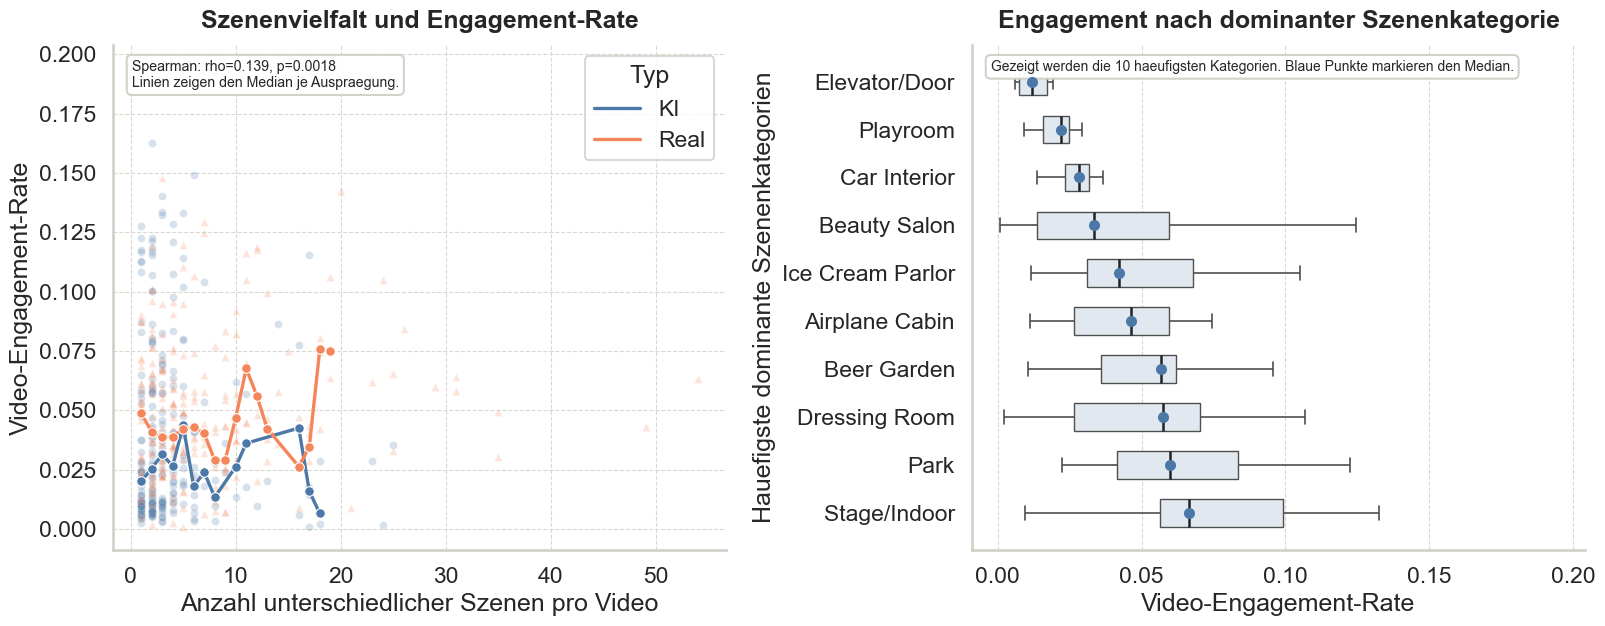

,Metrik,method,Spearman_rho,p_Wert
0,scene_unique_labels,Spearman,0.1393,0.0018


,Metrik,analysis,stat,p_Wert,n,R2,k_dummies
0,scene_top1_label,ANOVA,1.5836,0.0105,500,NaN,NaN
1,scene_top1_label,Dummy-Regression,NaN,NaN,500,0.2745,110.0


In [18]:
# Korrelations-/Engagement-Analysen laut Tabelle:
# - scene_unique_labels: Spearman
# - scene_top1_label: ANOVA + Dummy-Regression

sns.set_theme(
    style='whitegrid',
    context='talk',
    rc={
        'axes.facecolor': 'white',
        'figure.facecolor': 'white',
        'grid.color': '#d9d9d2',
        'grid.linestyle': '--',
        'grid.linewidth': 0.8,
        'axes.edgecolor': '#d0d0c8',
    },
)

df_plot = df.copy()
df_plot['typ'] = df_plot['influencer_type'].map({'ai': 'KI', 'real': 'Real'}).fillna(df_plot['influencer_type'])
PALETTE_COLOR = {'KI': '#4C78A8', 'Real': '#F5855B'}
MARKER = {'KI': 'o', 'Real': '^'}

corr_results = []
anova_reg_results = []

if 'video_engagement_rate' in df_plot.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16.4, 6.6), gridspec_kw={'width_ratios': [1.05, 1.05]})
    ax_trend, ax_scene = axes

    # 1) Szenenvielfalt und Engagement: gruppierter Trend statt roher Punktwolke
    if 'scene_unique_labels' in df_plot.columns:
        plot_df = df_plot[['scene_unique_labels', 'video_engagement_rate', 'typ']].dropna().copy()
        rho, pval = spearmanr(plot_df['scene_unique_labels'], plot_df['video_engagement_rate'], nan_policy='omit')
        corr_results.append({'Metrik': 'scene_unique_labels', 'method': 'Spearman', 'Spearman_rho': rho, 'p_Wert': pval})

        for grp in ['KI', 'Real']:
            sub = plot_df[plot_df['typ'] == grp].copy()
            sns.scatterplot(
                data=sub,
                x='scene_unique_labels',
                y='video_engagement_rate',
                color=PALETTE_COLOR[grp],
                marker=MARKER[grp],
                edgecolor='white',
                linewidth=0.3,
                s=32,
                alpha=0.22,
                ax=ax_trend,
                legend=False,
            )
            grouped = (
                sub.groupby('scene_unique_labels')['video_engagement_rate']
                .agg(median='median', q1=lambda s: s.quantile(0.25), q3=lambda s: s.quantile(0.75), n='size')
                .reset_index()
            )
            grouped = grouped[grouped['n'] >= 3]
            if not grouped.empty:
                ax_trend.plot(grouped['scene_unique_labels'], grouped['median'], color=PALETTE_COLOR[grp], linewidth=2.4, label=grp)
                ax_trend.scatter(grouped['scene_unique_labels'], grouped['median'], color=PALETTE_COLOR[grp], s=48, edgecolor='white', linewidth=0.8, zorder=4)

        ax_trend.set_title('Szenenvielfalt und Engagement-Rate', pad=12, weight='semibold')
        ax_trend.set_xlabel('Anzahl unterschiedlicher Szenen pro Video')
        ax_trend.set_ylabel('Video-Engagement-Rate')
        ax_trend.legend(title='Typ', frameon=True, facecolor='white', edgecolor='#d0d0c8', loc='best')
        ax_trend.text(
            0.03,
            0.97,
            f'Spearman: rho={rho:.3f}, p={pval:.4f}\nLinien zeigen den Median je Auspraegung.',
            transform=ax_trend.transAxes,
            ha='left',
            va='top',
            fontsize=10.2,
            bbox=dict(boxstyle='round,pad=0.35', facecolor='white', edgecolor='#d0d0c8', alpha=0.96),
        )

    # 2) Engagement nach dominanter Szene: nur häufigste Kategorien
    if 'scene_top1_label' in df_plot.columns:
        analysis_df = df_plot[['scene_top1_label', 'video_engagement_rate']].dropna().copy()
        groups = [g['video_engagement_rate'].values for _, g in analysis_df.groupby('scene_top1_label') if len(g) > 1]
        if len(groups) >= 2:
            f_stat, p_val = f_oneway(*groups)
            anova_reg_results.append({'Metrik': 'scene_top1_label', 'analysis': 'ANOVA', 'stat': f_stat, 'p_Wert': p_val, 'n': len(analysis_df)})

        X = pd.get_dummies(analysis_df['scene_top1_label'], drop_first=True, dtype=float)
        if X.shape[1] > 0:
            X_mat = np.column_stack([np.ones(len(X)), X.values])
            y = analysis_df['video_engagement_rate'].values.astype(float)
            beta, *_ = np.linalg.lstsq(X_mat, y, rcond=None)
            y_hat = X_mat @ beta
            ss_res = np.sum((y - y_hat) ** 2)
            ss_tot = np.sum((y - y.mean()) ** 2)
            r2 = np.nan if ss_tot == 0 else 1 - (ss_res / ss_tot)
            anova_reg_results.append({'Metrik': 'scene_top1_label', 'analysis': 'Dummy-Regression', 'R2': r2, 'n': len(analysis_df), 'k_dummies': X.shape[1]})

        top_labels = analysis_df['scene_top1_label'].value_counts().head(10).index.tolist()
        plot_scene_df = analysis_df[analysis_df['scene_top1_label'].isin(top_labels)].copy()
        plot_scene_df['scene_label_plot'] = (
            plot_scene_df['scene_top1_label']
            .astype(str)
            .str.replace('_', ' ', regex=False)
            .str.strip()
            .str.title()
        )
        order = (
            plot_scene_df.groupby('scene_label_plot')['video_engagement_rate']
            .median()
            .sort_values()
            .index.tolist()
        )
        sns.boxplot(
            data=plot_scene_df,
            y='scene_label_plot',
            x='video_engagement_rate',
            order=order,
            color='#dfe8f3',
            width=0.58,
            fliersize=0,
            boxprops={'edgecolor': '#4f4f4f'},
            whiskerprops={'linewidth': 1.2, 'color': '#4f4f4f'},
            capprops={'linewidth': 1.2, 'color': '#4f4f4f'},
            medianprops={'color': '#222222', 'linewidth': 1.8},
            ax=ax_scene,
        )
        scene_medians = plot_scene_df.groupby('scene_label_plot')['video_engagement_rate'].median().reindex(order)
        ax_scene.scatter(scene_medians.values, np.arange(len(scene_medians)), color='#4C78A8', s=42, zorder=4)
        ax_scene.set_title('Engagement nach dominanter Szenenkategorie', pad=12, weight='semibold')
        ax_scene.set_xlabel('Video-Engagement-Rate')
        ax_scene.set_ylabel('Hauefigste dominante Szenenkategorien')
        ax_scene.text(
            0.03,
            0.97,
            'Gezeigt werden die 10 haeufigsten Kategorien. Blaue Punkte markieren den Median.',
            transform=ax_scene.transAxes,
            ha='left',
            va='top',
            fontsize=10.0,
            bbox=dict(boxstyle='round,pad=0.35', facecolor='white', edgecolor='#d0d0c8', alpha=0.96),
        )

    for ax in axes:
        sns.despine(ax=ax, top=True, right=True)

    plt.tight_layout()
    plt.show()
else:
    print('video_engagement_rate column not available; skipping correlation/regression analysis.')

corr_df = pd.DataFrame(corr_results).round(4)
anova_reg_df = pd.DataFrame(anova_reg_results).round(4)
display(corr_df)
display(anova_reg_df)


In [13]:
print('Kurzinterpretation:')

def sig_label(p):
    return 'signifikant' if pd.notna(p) and p < 0.05 else 'nicht signifikant'

if 'results_df' in globals() and not results_df.empty:
    row = results_df.iloc[0]
    mean_diff = row['mean_ai'] - row['mean_real']
    direction = 'hoeher bei KI' if mean_diff > 0 else ('hoeher bei Real' if mean_diff < 0 else 'kein Unterschied')
    print(f"- Szenenvielfalt (scene_unique_labels, Mann-Whitney): {sig_label(row['u_p'])} (p={row['u_p']:.4f}). Interpretation: Höhere Vielfalt kann auf abwechslungsreichere Inszenierung hindeuten ({direction}).")

if 'chi2_df' in globals() and not chi2_df.empty:
    row = chi2_df.iloc[0]
    print(f"- Szenenlabel (scene_top1_label, Chi²): {sig_label(row['p_value'])} (chi2={row['chi2']:.2f}, p={row['p_value']:.4f}). Interpretation: Bestimmte Szenentypen treten je Gruppe unterschiedlich haeufig auf.")

if 'corr_df' in globals() and not corr_df.empty:
    row = corr_df.iloc[0]
    rho = row['Spearman_rho']; p = row['p_Wert']
    direction = 'positiv' if rho > 0 else ('negativ' if rho < 0 else 'neutral')
    print(f"- Engagement ~ scene_unique_labels (Spearman): {sig_label(p)} (rho={rho:.3f}, p={p:.4f}). Interpretation: {direction}er Zusammenhang; positive Werte sprechen für besseren Output bei hoher Vielfalt.")

if 'anova_reg_df' in globals() and not anova_reg_df.empty:
    for _, row in anova_reg_df.iterrows():
        if row['analysis'] == 'ANOVA':
            print(f"- Engagement ~ scene_top1_label (ANOVA): {sig_label(row['p_Wert'])} (F={row['stat']:.2f}, p={row['p_Wert']:.4f}).")
        else:
            print(f"- Engagement ~ scene_top1_label (Dummy-Regression): R²={row['R2']:.3f} (erklaerte Varianz).")


Kurzinterpretation:
- Szenenvielfalt (scene_unique_labels, Mann-Whitney): signifikant (p=0.0000). Interpretation: Höhere Vielfalt kann auf abwechslungsreichere Inszenierung hindeuten (höher bei Real).
- Szenenlabel (scene_top1_label, Chi²): signifikant (chi2=185.68, p=0.0000). Interpretation: Bestimmte Szenentypen treten je Gruppe unterschiedlich häufig auf.
- Engagement ~ scene_unique_labels (Spearman): signifikant (rho=0.139, p=0.0018). Interpretation: positiver Zusammenhang; positive Werte sprechen für besseren Output bei hoher Vielfalt.
- Engagement ~ scene_top1_label (ANOVA): signifikant (F=1.58, p=0.0105).
- Engagement ~ scene_top1_label (Dummy-Regression): R²=0.275 (erklaerte Varianz).
